# House MD — Metin Sınıflandırma Projesi
**Görev:** Tüm özellik sütunlarını kullanarak `correct_prediction` (hastalık adı) tahmin etmek

## Adım 1 — Ortam Kurulumu

In [ ]:
%pip install pandas scikit-learn matplotlib seaborn scipy snowballstemmer gensim lightgbm

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, json, warnings
warnings.filterwarnings('ignore')

from scipy.sparse import hstack, csr_matrix
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

print('Kütüphaneler yüklendi.')

Kütüphaneler yüklendi.


## Adım 2 — Veri Yükleme ve EDA

In [36]:
df = pd.read_csv('Last_HouseMD_DataSet(Sayfa1).csv', sep=';', encoding='utf-8-sig')
print('Satır sayısı :', len(df))
print('Sütunlar     :', df.columns.tolist())
df.head(3)

Satır sayısı : 7282
Sütunlar     : ['season', 'episode', 'speaker', 'Symptom', 'Test', 'Drug', 'Procedure', 'Intent', 'diagnosis_stage', 'Sarcasm', 'Emotion', 'Organ', 'correct_prediction', 'model_prediction', 'text', 'medical_entities']


,season,episode,speaker,Symptom,Test,Drug,Procedure,Intent,diagnosis_stage,Sarcasm,Emotion,Organ,correct_prediction,model_prediction,text,medical_entities
0,1,1,Wilson,nöbet,NaN,NaN,NaN,açıklama,hipotez,0,nötr,beyin,nörosistiserkozis,NaN,29 yaşında bir kadın hasta; ilk nöbetini bir a...,"[{""text"": ""nöbet"", ""type"": ""Symptom""}]"
1,1,1,Wilson,afazi,NaN,NaN,NaN,açıklama,hipotez,0,nötr,beyin,nörosistiserkozis,NaN,"Konuşma yetisini kaybetmiş, bebek gibi anlamsı...","[{""text"": ""afazi"", ""type"": ""Symptom""}]"
2,1,1,Wilson,zihinsel durum bozukluğu,NaN,NaN,NaN,açıklama,hipotez,0,nötr,beyin,nörosistiserkozis,NaN,Mental durumu giderek kötüleşiyor.,"[{""text"": ""zihinsel durum bozukluğu"", ""type"": ..."


In [37]:
bos = df.isnull().sum().sort_values(ascending=False)
pd.DataFrame({'Boş Sayısı': bos, 'Boş %': (bos / len(df) * 100).round(1)})

,Boş Sayısı,Boş %
model_prediction,5874,80.7
Procedure,5067,69.6
Drug,5049,69.3
Test,4613,63.3
Symptom,2637,36.2
Organ,2164,29.7
correct_prediction,1470,20.2
Intent,200,2.7
medical_entities,139,1.9
Emotion,2,0.0


In [38]:
print('correct_prediction unique:', df['correct_prediction'].nunique())
print(df['correct_prediction'].value_counts().head(25))

correct_prediction unique: 654
correct_prediction
nörosistiserkozis                                                   422
none                                                                192
1                                                                   180
melanom                                                             100
fosmet ile kontamine kıyafetlere bağlı organofosfat zehirlenmesi     69
Travma Sonrası Siringomyeli                                          65
amiloidoz                                                            64
kimerizm                                                             63
Şizofreni                                                            62
radyasyon zehirlenmesi                                               61
Orak hücre taşıyıcılığı                                              61
Timoma                                                               60
ekinokok                                                             60
kalp yetmezliğ

### Metin Uzunlukları

In [ ]:
df['text_len'] = df['text'].dropna().str.split().str.len()
print(df['text_len'].describe().round(1))

plt.figure(figsize=(10, 4))
df['text_len'].plot(kind='hist', bins=40, color='steelblue', edgecolor='black')
plt.title('Diyalog Kelime Sayısı Dağılımı')
plt.xlabel('Kelime Sayısı')
plt.ylabel('Frekans')
plt.tight_layout()
plt.show()

## Adım 3 — Hedef Sütun Temizleme (Top 20 Hastalık)

In [39]:
GURULTULU = {'', 'none', 'None', 'NONE', '1', '0', '-', 'nan'}
df['hedef'] = df['correct_prediction'].astype(str).str.strip()
df = df[~df['hedef'].isin(GURULTULU)].copy()

TOP_N = 20
top20 = df['hedef'].value_counts().head(TOP_N).index.tolist()
df = df[df['hedef'].isin(top20)].reset_index(drop=True)

print(f'Top {TOP_N} hastalık — kalan satır: {len(df)}')
print(df['hedef'].value_counts())

Top 20 hastalık — kalan satır: 1582
hedef
nörosistiserkozis                                                   422
melanom                                                             100
fosmet ile kontamine kıyafetlere bağlı organofosfat zehirlenmesi     69
Travma Sonrası Siringomyeli                                          65
amiloidoz                                                            64
kimerizm                                                             63
Şizofreni                                                            62
radyasyon zehirlenmesi                                               61
Orak hücre taşıyıcılığı                                              61
Timoma                                                               60
ekinokok                                                             60
kalp yetmezliği (ipecac fazlalığına bağlı)                           56
testiküler kanser                                                    55
kalıtsal hemorajik tel

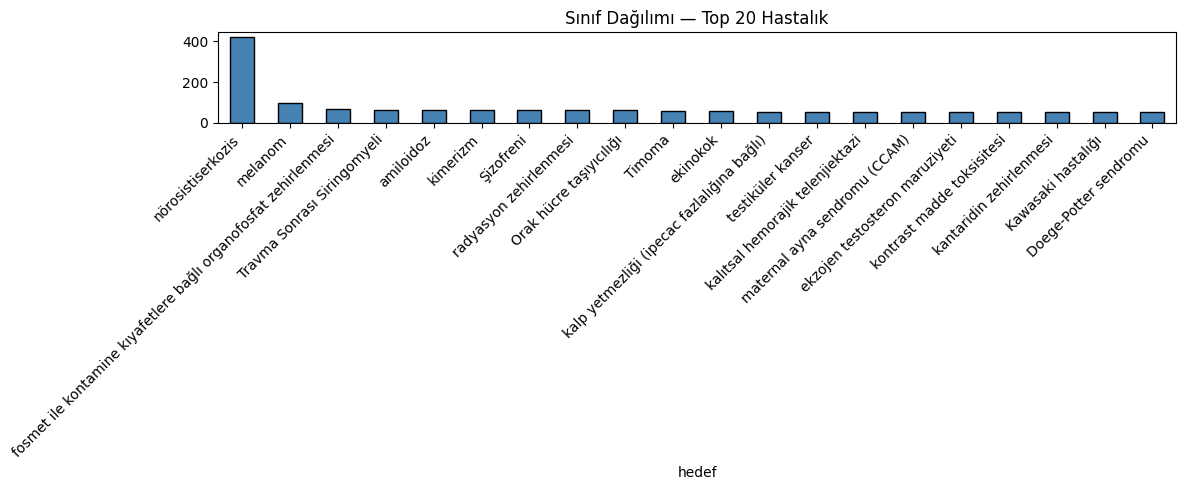

In [40]:
plt.figure(figsize=(12, 5))
df['hedef'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Sınıf Dağılımı — Top 20 Hastalık')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Adım 4 — Özellik Mühendisliği

### 4a — Metin Ön İşleme + TF-IDF

Uyguladığımız adımlar:

| # | Adım | Ne yapıyor? |
|---|------|-------------|
| 1 | **Temizleme** | HTML etiketleri, özel karakterler ve sayılar kaldırılır |
| 2 | **Tokenization** | Cümle boşluklardan kelime listesine bölünür |
| 3 | **Stop-words** | "bir", "ve", "bu" gibi düşük bilgili kelimeler atılır |
| 4 | **Stemming** | Snowball Türkçe stemmer ile kelimeler köklerine indirgenir |
| 5 | **Lowercasing** | Tüm metin küçük harfe çevrilir |

In [ ]:
import snowballstemmer

# ── 3. Stop-words — Türkçe ────────────────────────────────────────────────────
TURKCE_STOPWORDS = {
    'bir', 've', 'bu', 'da', 'de', 'ile', 'için', 'mi', 'mu', 'mı', 'mü',
    'var', 'yok', 'ki', 'ne', 'o', 'ben', 'sen', 'biz', 'siz', 'onlar',
    'ama', 'fakat', 'lakin', 'ancak', 'ya', 'veya', 'yahut', 'hem',
    'çünkü', 'eğer', 'ise', 'gibi', 'kadar', 'daha', 'en', 'çok', 'az',
    'her', 'hiç', 'bazı', 'tüm', 'bütün', 'hangi', 'nasıl', 'neden', 'niçin',
    'şu', 'şey', 'olan', 'olarak', 'üzere', 'göre', 'karşı', 'sonra', 'önce',
    'yani', 'sadece', 'bile', 'dahi', 'hatta', 'artık', 'zaten', 'belki',
    'acaba', 'peki', 'evet', 'hayır', 'tamam', 'değil', 'diye', 'bunu',
    'buna', 'bunun', 'şunu', 'şuna', 'onun', 'beni', 'seni', 'onu',
    'bizi', 'sizi', 'onları', 'bende', 'sende', 'onda',
}

def on_isle(metin):
    """Lowercasing + HTML / özel karakter / sayı temizleme."""
    metin = str(metin).lower()                 # 5. Lowercasing
    metin = re.sub(r'<[^>]+>', ' ', metin)     # 1. HTML etiketi kaldırma
    metin = re.sub(r'[^\w\s]', ' ', metin)     # 1. Özel karakter kaldırma
    metin = re.sub(r'\d+', ' ', metin)         # 1. Sayı kaldırma
    return re.sub(r'\s+', ' ', metin).strip()

def on_isle_tam(metin):
    """Temizleme → tokenization → stop-words.
    Stemming uygulanmıyor: Snowball Türkçe stemmer tıbbi kelimelerde
    anlam bozuyor (örn. kadın→kadı, hasta→has)."""
    metin = on_isle(metin)
    tokens = metin.split()                                    # 2. Tokenization
    tokens = [t for t in tokens                               # 3. Stop-words
              if t not in TURKCE_STOPWORDS and len(t) > 1]   # 2 harfli tıbbi kelimeler korunur
    return ' '.join(tokens)

def isle_ve_etiketle(row):
    metin = on_isle_tam(row['text'])
    return ('sarcasm ' + metin) if str(row['Sarcasm']).strip() == '1' else metin

df['text_clean'] = df.apply(isle_ve_etiketle, axis=1)

TIBBI = ['Symptom', 'Test', 'Drug', 'Procedure', 'Organ']
df['tibbi_metin'] = df[TIBBI].fillna('').apply(
    lambda row: ' '.join(row.values.astype(str)), axis=1
).apply(on_isle_tam)

# ── Örnek: ön işleme adımlarını karşılaştır ──────────────────────────────────
ornek = df['text'].dropna().iloc[0]
print('Ham metin   :', ornek[:100])
print('Temizlenmiş :', on_isle_tam(ornek)[:100])
print()

# ── Vectorizer'lar ────────────────────────────────────────────────────────────
tfidf_text  = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
tfidf_tibbi = TfidfVectorizer(max_features=3000)

X_text  = tfidf_text.fit_transform(df['text_clean'])
X_tibbi = tfidf_tibbi.fit_transform(df['tibbi_metin'])

sarcasm_n = (df['Sarcasm'].astype(str).str.strip() == '1').sum()
print(f'Alaycı: {sarcasm_n} — Normal: {len(df) - sarcasm_n}')
print('X_text  :', X_text.shape)
print('X_tibbi :', X_tibbi.shape)

### 4a-2 — Word Embeddings (Word2Vec)

Kelimeler arası anlamsal ilişkiyi korur: "nöbet" ve "konvülsiyon" yakın vektörlere sahip olur.  
Her diyalog için cümledeki kelime vektörlerinin **ortalaması** alınarak sabit boyutlu (100) bir temsil elde edilir.

In [ ]:
from gensim.models import Word2Vec

W2V_SIZE = 100

# Corpus: temizlenmiş metinleri token listelerine çevir
corpus = [text.split() for text in df['text_clean']]

# Word2Vec modelini veri üzerinde sıfırdan eğit
w2v_model = Word2Vec(
    sentences=corpus,
    vector_size=W2V_SIZE,
    window=5,
    min_count=2,
    workers=4,
    epochs=15,
    seed=42,
)

def mean_w2v(text, model, size):
    """Cümledeki bilinen kelime vektörlerinin ortalamasını döndürür."""
    tokens = text.split()
    vectors = [model.wv[t] for t in tokens if t in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(size)

X_w2v = np.vstack([mean_w2v(t, w2v_model, W2V_SIZE) for t in df['text_clean']])

print('Kelime dağarcığı boyutu :', len(w2v_model.wv))
print('X_w2v                  :', X_w2v.shape)

# En yakın 5 komşu — anlam kontrolü
for kelime in ['nöbet', 'kanser', 'ilaç']:
    if kelime in w2v_model.wv:
        komsular = [k for k, _ in w2v_model.wv.most_similar(kelime, topn=5)]
        print(f'  {kelime:<12} → {komsular}')

### 4b — Kategorik (One-Hot)

In [42]:
KATEGORIK = ['Intent', 'diagnosis_stage', 'Emotion', 'speaker']
df_kat = df[KATEGORIK].fillna('bilinmiyor').astype(str)
for col in KATEGORIK:
    nadir = df_kat[col].value_counts()
    df_kat[col] = df_kat[col].replace(nadir[nadir < 5].index, 'diger')

kat_dummies = pd.get_dummies(df_kat, drop_first=True).astype(float)
KAT_KOLONLAR = kat_dummies.columns.tolist()  # canlı test için kolon sırası kaydediliyor

X_kat_sparse = csr_matrix(kat_dummies.values)
print('X_kategorik :', X_kat_sparse.shape)
print('Kolon sayısı :', len(KAT_KOLONLAR))

X_kategorik : (1582, 81)
Kolon sayısı : 81


### 4c — JSON Çözümleme: medical_entities

In [43]:
TYPE_MAP = {
    'Disease': 'ent_Disease', 'Diagnosis': 'ent_Disease', 'DS': 'ent_Disease',
    'Condition': 'ent_Disease', 'COND': 'ent_Disease',
    'Symptom': 'ent_Symptom', 'SYMP': 'ent_Symptom',
    'Test': 'ent_Test', 'TEST': 'ent_Test', 'Test Sonucu': 'ent_Test',
    'Drug': 'ent_Drug', 'DRUG': 'ent_Drug', 'Medication': 'ent_Drug',
    'Procedure': 'ent_Procedure', 'PROC': 'ent_Procedure', 'Treatment': 'ent_Procedure',
    'Anatomy': 'ent_Anatomy', 'Organ': 'ent_Anatomy', 'ORG': 'ent_Anatomy',
}
ENT_COLS = ['ent_Disease', 'ent_Symptom', 'ent_Test', 'ent_Drug', 'ent_Procedure', 'ent_Anatomy']

def parse_entities(json_str):
    sonuc = {col: [] for col in ENT_COLS}
    try:
        for e in json.loads(str(json_str)):
            tip = TYPE_MAP.get(e.get('type', ''))
            if tip:
                sonuc[tip].append(str(e.get('text', '')).lower())
    except Exception:
        pass
    return {col: ' '.join(v) for col, v in sonuc.items()}

ent_df = df['medical_entities'].fillna('[]').apply(parse_entities).apply(pd.Series)
df = pd.concat([df, ent_df], axis=1)

df['ent_all'] = df[ENT_COLS].fillna('').apply(
    lambda row: ' '.join(row.values.astype(str)), axis=1
).apply(on_isle)

# Vectorizer kaydediliyor — canlı test için gerekli
tfidf_entity = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))
X_entity = tfidf_entity.fit_transform(df['ent_all'])
print('X_entity :', X_entity.shape)

X_entity : (1582, 3000)


### 4c-2 — Entity Sayıları (Sayısal Özellikler)

Her satır için kaç adet semptom, ilaç, test, prosedür, anatomi ve hastalık entity'si geçtiği sayılır.

In [ ]:
def count_entities(json_str):
    """Her entity tipini sayar, toplam entity adedini de döndürür."""
    counts = {col: 0 for col in ENT_COLS}
    try:
        for e in json.loads(str(json_str)):
            tip = TYPE_MAP.get(e.get('type', ''))
            if tip:
                counts[tip] += 1
    except Exception:
        pass
    return counts

ENT_COUNT_COLS = [col.replace('ent_', 'n_') for col in ENT_COLS]

ent_counts = (
    df['medical_entities']
    .fillna('[]')
    .apply(count_entities)
    .apply(pd.Series)
    .rename(columns=dict(zip(ENT_COLS, ENT_COUNT_COLS)))
)
ent_counts['n_total'] = ent_counts.sum(axis=1)

df = pd.concat([df, ent_counts], axis=1)

X_ent_counts = csr_matrix(ent_counts.values.astype(float))

print('Oluşturulan sayısal sütunlar:', ent_counts.columns.tolist())
print('X_ent_counts :', X_ent_counts.shape)
print()
print(ent_counts.describe().round(2))

## Adım 5 — Özellik Birleştirme

In [ ]:
SAYISAL = ['Sarcasm', 'season', 'episode']
X_say = csr_matrix(df[SAYISAL].fillna(0).astype(float).values)

X_w2v_sparse = csr_matrix(X_w2v)

X = hstack([X_text, X_tibbi, X_entity, X_kat_sparse, X_say, X_w2v_sparse, X_ent_counts])
y = df['hedef']

print('Özellik grupları:')
print(f'  X_text       : {X_text.shape}')
print(f'  X_tibbi      : {X_tibbi.shape}')
print(f'  X_entity     : {X_entity.shape}')
print(f'  X_kategorik  : {X_kat_sparse.shape}')
print(f'  X_sayisal    : {X_say.shape}')
print(f'  X_w2v        : {X_w2v_sparse.shape}')
print(f'  X_ent_counts : {X_ent_counts.shape}')
print(f'  ─────────────────────')
print(f'  TOPLAM       : {X.shape}')

## Adım 6 — Train / Test Bölme

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('Eğitim seti:', X_train.shape)
print('Test seti  :', X_test.shape)

Eğitim seti: (1265, 9236)
Test seti  : (317, 9236)


## Adım 7 — Model Eğitimi

In [46]:
from sklearn.model_selection import cross_val_score

modeller = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=42,
        class_weight='balanced',   # azınlık sınıflara ağırlık ver
        C=1.0
    ),
    'LinearSVC': LinearSVC(
        max_iter=2000, random_state=42,
        class_weight='balanced',
        C=1.0
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, random_state=42, n_jobs=-1,
        class_weight='balanced'
    ),
}

sonuclar = {}
cv_sonuclar = {}

for isim, model in modeller.items():
    # 5-fold cross-validation (daha güvenilir)
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1_macro', n_jobs=-1)
    cv_sonuclar[isim] = cv_scores

    # Test seti tahmini
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    sonuclar[isim] = y_pred

    acc = (y_pred == y_test).mean()
    print(f'{isim:<25}  Test Acc: {acc:.4f}  |  CV F1-macro: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

Logistic Regression        Test Acc: 0.8170  |  CV F1-macro: 0.8003 ± 0.0231
LinearSVC                  Test Acc: 0.7823  |  CV F1-macro: 0.7629 ± 0.0226
Random Forest              Test Acc: 0.7161  |  CV F1-macro: 0.5922 ± 0.0237


### Adım 7b — Hiperparametre Optimizasyonu (LR) + LightGBM

- **GridSearchCV**: Logistic Regression için en iyi `C` değeri 5-fold CV ile aranır.  
- **LightGBM**: Hataları sırayla öğrenen gradient boosting modeli; kategorik ve sayısal özellikleri TF-IDF ile birlikte dengeli işler.

In [ ]:
from sklearn.model_selection import GridSearchCV
from lightgbm import LGBMClassifier

# ── 1. Logistic Regression — C parametresi tuning ────────────────────────────
print('GridSearchCV çalışıyor (LR)...')
gs_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    param_grid={'C': [0.01, 0.1, 1, 10, 100]},
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
)
gs_lr.fit(X_train, y_train)

best_lr        = gs_lr.best_estimator_
y_pred_lr_best = best_lr.predict(X_test)
acc_lr_best    = (y_pred_lr_best == y_test).mean()
cv_lr_best     = cross_val_score(best_lr, X_train, y_train, cv=5, scoring='f1_macro', n_jobs=-1)

print(f'Tuned LR  →  En iyi C : {gs_lr.best_params_["C"]}')
print(f'           CV F1-macro : {cv_lr_best.mean():.4f} ± {cv_lr_best.std():.4f}')
print(f'           Test Acc    : {acc_lr_best:.4f}')

# ── 2. LightGBM ───────────────────────────────────────────────────────────────
print('\nLightGBM eğitiliyor...')
lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)
lgbm.fit(X_train, y_train)

y_pred_lgbm = lgbm.predict(X_test)
acc_lgbm    = (y_pred_lgbm == y_test).mean()
cv_lgbm     = cross_val_score(lgbm, X_train, y_train, cv=5, scoring='f1_macro', n_jobs=-1)

print(f'LightGBM  →  Test Acc    : {acc_lgbm:.4f}')
print(f'             CV F1-macro : {cv_lgbm.mean():.4f} ± {cv_lgbm.std():.4f}')

# ── Karşılaştırma tablosuna ekle ──────────────────────────────────────────────
sonuclar['Tuned LR']   = y_pred_lr_best
sonuclar['LightGBM']   = y_pred_lgbm
cv_sonuclar['Tuned LR']  = cv_lr_best
cv_sonuclar['LightGBM']  = cv_lgbm
modeller['Tuned LR']   = best_lr
modeller['LightGBM']   = lgbm

# ── Tüm modellerin özet karşılaştırması ──────────────────────────────────────
print('\n{:<30} {:>10} {:>14}'.format('Model', 'Test Acc', 'CV F1-macro'))
print('-' * 56)
for isim in modeller:
    pred = sonuclar[isim]
    acc  = (pred == y_test).mean()
    f1   = cv_sonuclar[isim].mean()
    print(f'{isim:<30} {acc:>10.4f} {f1:>14.4f}')

## Adım 8 — Değerlendirme

In [47]:
# En iyi model: Logistic Regression (0.830 > LinearSVC 0.782)
en_iyi = 'Logistic Regression'
print(f'=== {en_iyi} — Classification Report ===')
print(classification_report(y_test, sonuclar[en_iyi]))

=== Logistic Regression — Classification Report ===
                                                                  precision    recall  f1-score   support

                                           Doege-Potter sendromu       0.62      0.73      0.67        11
                                              Kawasaki hastalığı       0.92      1.00      0.96        11
                                         Orak hücre taşıyıcılığı       1.00      1.00      1.00        12
                                                          Timoma       0.69      0.75      0.72        12
                                     Travma Sonrası Siringomyeli       0.92      0.85      0.88        13
                                                       amiloidoz       1.00      1.00      1.00        13
                                                        ekinokok       0.62      0.67      0.64        12
                                  ekzojen testosteron maruziyeti       0.53      0.73      0.62    

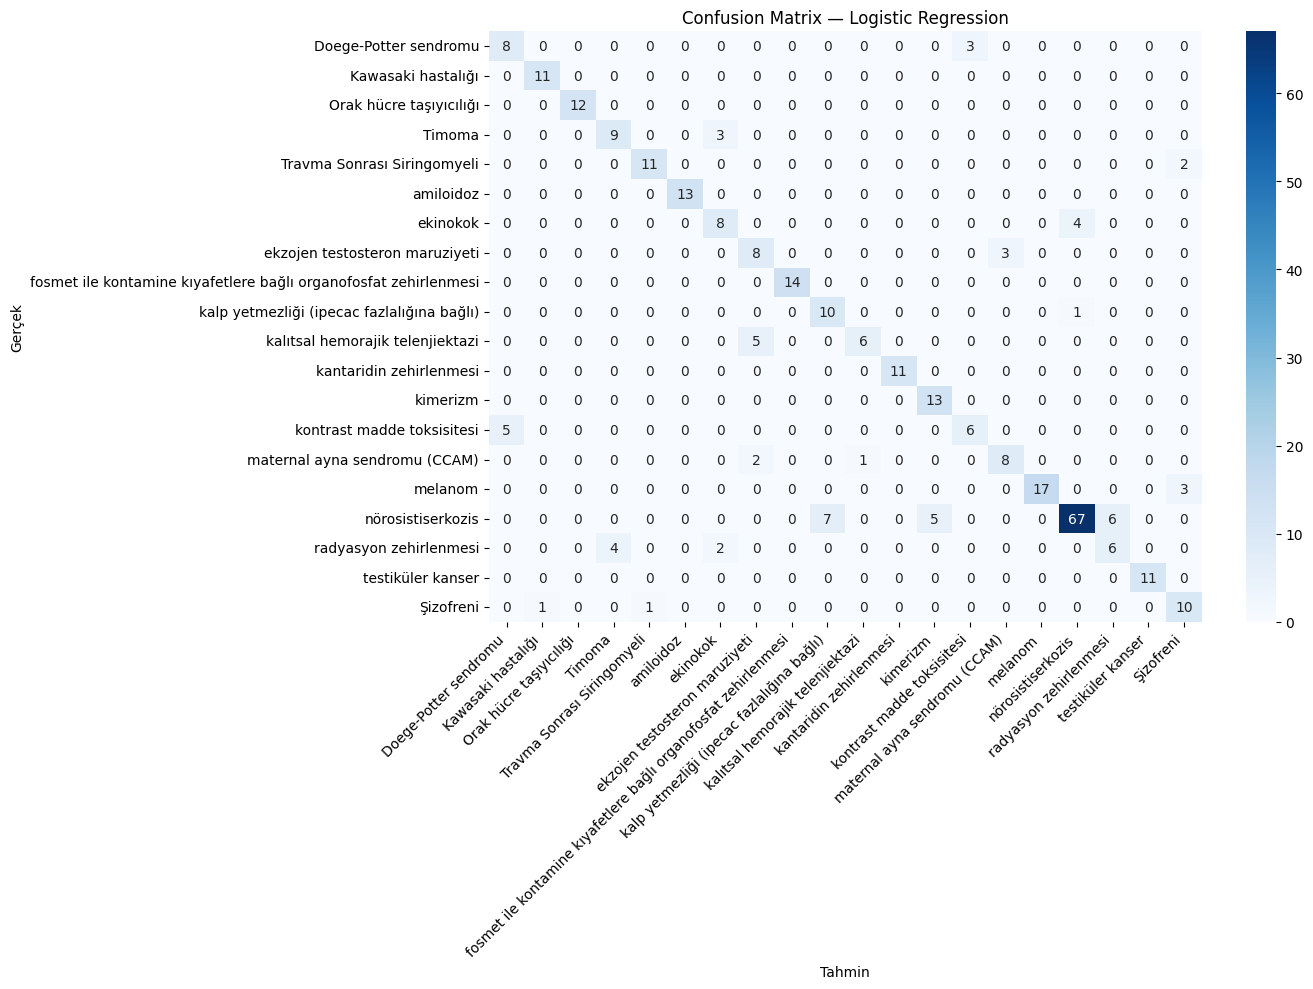

In [48]:
siniflar = sorted(y.unique())
cm = confusion_matrix(y_test, sonuclar[en_iyi], labels=siniflar)

plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=siniflar, yticklabels=siniflar, cmap='Blues')
plt.title(f'Confusion Matrix — {en_iyi}')
plt.xlabel('Tahmin')
plt.ylabel('Gerçek')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

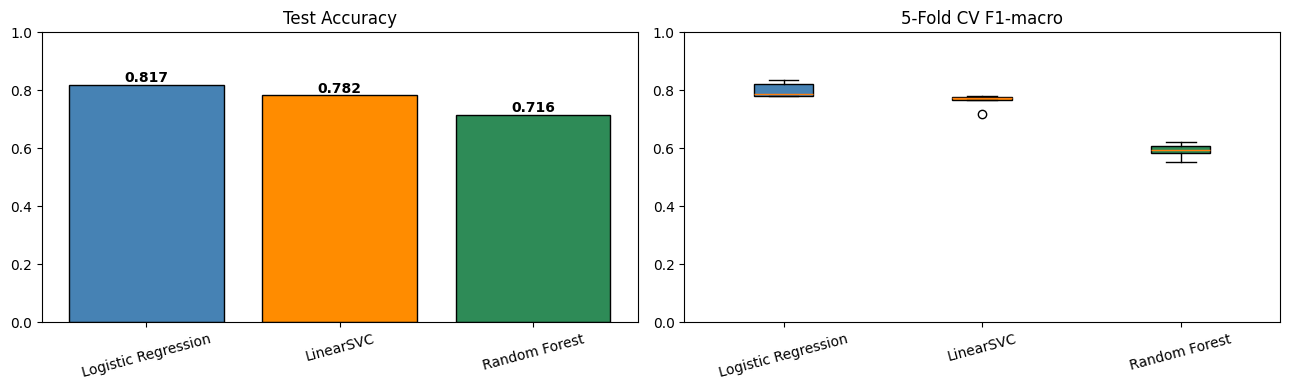

In [49]:
# CV F1-macro karşılaştırması (daha güvenilir metrik)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Sol: Test Accuracy
acc_list = {isim: (pred == y_test).mean() for isim, pred in sonuclar.items()}
bars = axes[0].bar(acc_list.keys(), acc_list.values(),
                   color=['steelblue', 'darkorange', 'seagreen'], edgecolor='black')
axes[0].set_ylim(0, 1)
axes[0].set_title('Test Accuracy')
axes[0].tick_params(axis='x', rotation=15)
for bar, v in zip(bars, acc_list.values()):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + 0.01,
                 f'{v:.3f}', ha='center', fontweight='bold')

# Sağ: CV F1-macro (boxplot — varyansı da gösterir)
f1_data = [cv_sonuclar[m] for m in modeller]
bp = axes[1].boxplot(f1_data, labels=list(modeller.keys()), patch_artist=True)
renkler = ['steelblue', 'darkorange', 'seagreen']
for patch, renk in zip(bp['boxes'], renkler):
    patch.set_facecolor(renk)
axes[1].set_ylim(0, 1)
axes[1].set_title('5-Fold CV F1-macro')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## Adım 9 — Canlı Test

In [50]:
def tahmin_et(
    text,
    sarcasm=0,
    symptom='', test_col='', drug='', procedure='', organ='',
    intent='bilinmiyor', diagnosis_stage='bilinmiyor',
    emotion='bilinmiyor', speaker='bilinmiyor',
    season=1, episode=1,
    medical_entities_json='[]'
):
    """
    Tek bir diyalog satırı için hastalık tahmini yapar.

    Zorunlu: text
    Opsiyonel: diğer tüm alanlar (boş bırakılabilir)
    """
    en_iyi_model = modeller['Logistic Regression']

    # --- Metin ---
    temiz = on_isle(text)
    if sarcasm == 1:
        temiz = 'sarcasm ' + temiz
    X_t = tfidf_text.transform([temiz])

    # --- Tıbbi metin ---
    tibbi = on_isle(' '.join([symptom, test_col, drug, procedure, organ]))
    X_ti = tfidf_tibbi.transform([tibbi])

    # --- Medical entities JSON ---
    ent = parse_entities(medical_entities_json)
    ent_metin = on_isle(' '.join(ent.values()))
    X_e = tfidf_entity.transform([ent_metin])

    # --- Kategorik (eğitimdeki kolon sırası korunmalı) ---
    satir = pd.DataFrame([{
        'Intent': intent,
        'diagnosis_stage': diagnosis_stage,
        'Emotion': emotion,
        'speaker': speaker
    }])
    satir_kat = pd.get_dummies(satir).reindex(columns=KAT_KOLONLAR, fill_value=0).astype(float)
    X_k = csr_matrix(satir_kat.values)

    # --- Sayısal ---
    X_s = csr_matrix([[float(sarcasm), float(season), float(episode)]])

    # --- Birleştir ve tahmin et ---
    X_input = hstack([X_t, X_ti, X_e, X_k, X_s])
    tahmin = en_iyi_model.predict(X_input)[0]

    # Olasılık skoru (LR destekliyor)
    proba = en_iyi_model.predict_proba(X_input)[0]
    sinif_idx = list(en_iyi_model.classes_).index(tahmin)
    guven = proba[sinif_idx]

    # Top 3 tahmin
    top3_idx = proba.argsort()[::-1][:3]
    top3 = [(en_iyi_model.classes_[i], round(proba[i], 3)) for i in top3_idx]

    print(f'Metin       : {text}')
    print(f'Tahmin      : {tahmin}')
    print(f'Güven       : %{guven*100:.1f}')
    print(f'Top 3       :')
    for i, (sinif, p) in enumerate(top3, 1):
        print(f'  {i}. {sinif:<45} %{p*100:.1f}')
    return tahmin

### Test Örnekleri

In [51]:
# --- Test 1: Sadece metin (minimum girdi) ---
print('=' * 60)
print('TEST 1 — Sadece metin')
print('=' * 60)
tahmin_et(
    text="Hastanın nöbet geçirdiğini ve MR'da lezyon bulunduğunu öğrendik."
)

print()

# --- Test 2: Metin + tıbbi bilgiler ---
print('=' * 60)
print('TEST 2 — Metin + tıbbi alanlar')
print('=' * 60)
tahmin_et(
    text="Melanom tanısı koyuyorum, deri lezyonu bunu destekliyor.",
    symptom="deri lezyonu",
    diagnosis_stage="tanı",
    speaker="House",
    emotion="nötr"
)

print()

# --- Test 3: Alaycı cümle ---
print('=' * 60)
print('TEST 3 — Alaycı cümle (Sarcasm=1)')
print('=' * 60)
tahmin_et(
    text="Tabii ki de bu bir şizofreni vakası, başka ne olabilir ki.",
    sarcasm=1,
    speaker="House",
    emotion="alaycı"
)

print()

# --- Test 4: Kendi metninizi buraya yazın ---
print('=' * 60)
print('TEST 4 — Kendi test cümleniz')
print('=' * 60)
tahmin_et(
    text="Buraya kendi test cümlenizi yazın."
)

TEST 1 — Sadece metin
Metin       : Hastanın nöbet geçirdiğini ve MR'da lezyon bulunduğunu öğrendik.
Tahmin      : radyasyon zehirlenmesi
Güven       : %45.8
Top 3       :
  1. radyasyon zehirlenmesi                        %45.8
  2. kimerizm                                      %20.4
  3. amiloidoz                                     %13.8

TEST 2 — Metin + tıbbi alanlar
Metin       : Melanom tanısı koyuyorum, deri lezyonu bunu destekliyor.
Tahmin      : radyasyon zehirlenmesi
Güven       : %37.4
Top 3       :
  1. radyasyon zehirlenmesi                        %37.4
  2. kimerizm                                      %31.7
  3. amiloidoz                                     %13.2

TEST 3 — Alaycı cümle (Sarcasm=1)
Metin       : Tabii ki de bu bir şizofreni vakası, başka ne olabilir ki.
Tahmin      : radyasyon zehirlenmesi
Güven       : %48.4
Top 3       :
  1. radyasyon zehirlenmesi                        %48.4
  2. kimerizm                                      %19.9
  3. amiloidoz     

'radyasyon zehirlenmesi'